<a href="https://colab.research.google.com/github/MamadyMagass/DeepLearningProjetcs/blob/main/ConvolutionalNeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# mkdir -p ~/.kaggle && echo KGAT_898f59ef482cef0d581e5de94c42bed9 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
! kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [ ]:
! kaggle datasets list -s "dogs"

ref                                                 title                                       size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------  ------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset          Cats-vs-Dogs                           825979578  2020-03-12 05:34:30.730000         113058        995  0.875            
d4rklucif3r/cat-and-dogs                            Cat & Dogs                             228496389  2021-06-07 11:39:13.983000          10441        134  1                
jessicali9530/stanford-dogs-dataset                 Stanford Dogs Dataset                  786955428  2019-11-13 06:20:35.130000          76978       1162  0.75             
marquis03/cats-and-dogs                             Cats and Dogs                           10219362  2023-10-27 10:48:19.220000  

In [ ]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:07<00:00, 110MB/s]



### Count items in a folder

The following code counts the number of files and directories within a specified folder. You can change the `folder_path` variable to target a different directory.

In [ ]:
import os, shutil, pathlib

In [ ]:
original_dir = pathlib.Path("PetImages")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

In [ ]:
import shutil

if new_base_dir.exists():
    shutil.rmtree(new_base_dir)
    print(f"Removed existing directory: {new_base_dir}")
else:
    print(f"Directory not found: {new_base_dir}")

Removed existing directory: cats_vs_dogs_small


In [ ]:
def make_subset(subset_name, start_index, end_index):
  for category in ("cat", "dog"):
    dir = new_base_dir / subset_name / category
    os.makedirs(dir)
    # Filenames are simply the index, e.g., '0.jpg', '1.jpg'
    fnames = [f"{i}.jpg" for i in range(start_index, end_index)]
    print(fnames[:5])
    for fname in fnames:
      # Use .capitalize() to match 'Cat' and 'Dog' folder names for the source directory
      shutil.copyfile(src=original_dir / category.capitalize() / fname, dst=dir / fname)


In [ ]:
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg']
['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg']
['1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg']
['1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg']
['1500.jpg', '1501.jpg', '1502.jpg', '1503.jpg', '1504.jpg']
['1500.jpg', '1501.jpg', '1502.jpg', '1503.jpg', '1504.jpg']


In [ ]:
len(os.listdir(new_base_dir / "train" / "dog"))

1000

### Opening a JPEG Image

To open and view a JPEG image in Python, you can use the `Pillow` library, which is a fork of the Python Imaging Library (PIL). First, you need to import the `Image` module from Pillow.

In [ ]:
# Install Pillow if you haven't already
# %pip install Pillow

from PIL import Image
import matplotlib.pyplot as plt

Now, let's specify the path to an example JPEG image. We'll use one of the images created in the `cats_vs_dogs_small` dataset.

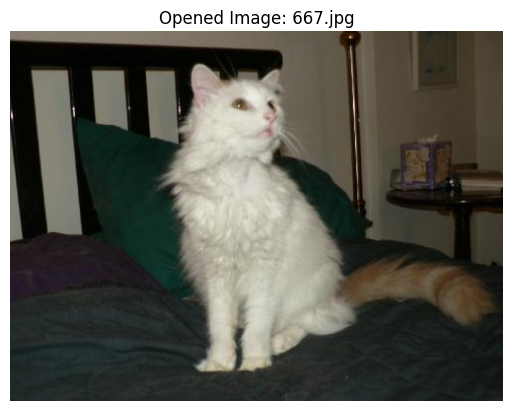

Image format: JPEG
Image size: (500, 375)
Image mode: RGB


In [ ]:
image_path = new_base_dir / "train" / "cat" / "667.jpg"

# Check if the image file exists
if image_path.exists():
    # Open the image
    img = Image.open(image_path)

    # Display the image using matplotlib
    plt.imshow(img)
    plt.axis('off') # Hide axes ticks and labels
    plt.title(f"Opened Image: {image_path.name}")
    plt.show()

    # You can also print some information about the image
    print(f"Image format: {img.format}")
    print(f"Image size: {img.size}")
    print(f"Image mode: {img.mode}")
else:
    print(f"Image not found at: {image_path}")

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow import keras

In [ ]:
from tensorflow.keras import layers

In [ ]:
inputs = keras.Input(shape=(180,180,3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size =3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size = 2)(x)
x = layers.Conv2D(filters=64, kernel_size =3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size = 2)(x)
x = layers.Conv2D(filters=128, kernel_size =3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size = 2)(x)
x = layers.Conv2D(filters=256, kernel_size =3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size = 2)(x)
x = layers.Conv2D(filters=256, kernel_size =3, activation = "relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation = "sigmoid")(x)
model = keras.Model(inputs = inputs, outputs = outputs )

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer = "rmsprop",
              metrics = ["accuracy"])

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size = (180,180),
    batch_size = 32
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size = (180,180),
    batch_size = 32
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size = (180,180),
    batch_size = 32
)

Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
# Explanation of the error:
# The `InvalidArgumentError: Input is empty.` occurs because TensorFlow's image decoder
# encountered an image file that was empty, incomplete, or corrupted when trying to
# load data from the `train_dataset`. This means one or more image files
# in your 'cats_vs_dogs_small' directory are unreadable by the image loading utility.

# Diagnostic step:
# Before attempting to re-run `model.fit`, it's important to identify and potentially
# remove these corrupted files. The following code will scan your image directories
# and attempt to open each image using the Pillow library, which can help detect issues.

import os
from PIL import Image # Ensure PIL is imported if not already

def check_for_corrupted_images(base_dir_path):
    print(f"Scanning for corrupted images in: {base_dir_path}")
    corrupted_count = 0
    # Assuming new_base_dir is a pathlib.Path object defined elsewhere in the notebook
    for subset in ["train", "validation", "test"]:
        for category in ["cat", "dog"]:
            current_dir = base_dir_path / subset / category
            if not current_dir.exists():
                print(f"Warning: Directory not found: {current_dir}")
                continue
            for filename in os.listdir(current_dir):
                file_path = current_dir / filename
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Verify the image file integrity
                except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
                    print(f"Corrupted or unreadable image found: {file_path} (Error: {e})")
                    corrupted_count += 1
                except Exception as e:
                    print(f"Unexpected error while checking {file_path}: {e}")
                    corrupted_count += 1
    if corrupted_count == 0:
        print("No corrupted or unreadable images found.")
        print("You can now uncomment and re-run the `model.fit` call below.")
    else:
        print(f"Found {corrupted_count} corrupted/unreadable images. Please remove them from the dataset directories or re-download the dataset.")
        print("After fixing, re-run this cell to verify, then uncomment and run `model.fit`.")

# Run the check
check_for_corrupted_images(new_base_dir)



Scanning for corrupted images in: cats_vs_dogs_small
No corrupted or unreadable images found.
You can now uncomment and re-run the `model.fit` call below.


In [ ]:

import os

# Construct the full path to the corrupted image
corrupted_file_path = new_base_dir / "train" / "cat" / "666.jpg"

# Check if the file exists before attempting to remove it
if corrupted_file_path.exists():
    os.remove(corrupted_file_path)
    print(f"Removed corrupted file: {corrupted_file_path}")
else:
    print(f"File not found: {corrupted_file_path}")

print("Please re-run the diagnostic cell (kEZOq8jALrNS) to confirm no other corrupted files remain.")

Removed corrupted file: cats_vs_dogs_small/train/cat/666.jpg
Please re-run the diagnostic cell (kEZOq8jALrNS) to confirm no other corrupted files remain.


In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size = (180,180),
    batch_size = 32
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size = (180,180),
    batch_size = 32
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size = (180,180),
    batch_size = 32
)

Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data = validation_dataset,
    callbacks = callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.5973 - loss: 0.6729 - val_accuracy: 0.5090 - val_loss: 0.6881
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.6298 - loss: 0.6473 - val_accuracy: 0.6620 - val_loss: 0.6105
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.6728 - loss: 0.6026 - val_accuracy: 0.6710 - val_loss: 0.5889
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.7094 - loss: 0.5583 - val_accuracy: 0.6800 - val_loss: 0.5816
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.7514 - loss: 0.5182 - val_accuracy: 0.6830 - val_loss: 0.5840
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.7609 - loss: 0.4884 - val_accuracy: 0.7240 - val_loss: 0.5452
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.7839 - loss: 0.4468 - val_accuracy: 0.6940 - val_loss: 0.6474
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.8234 - loss: 0.4102 - val_accuracy: 0.6590 - v

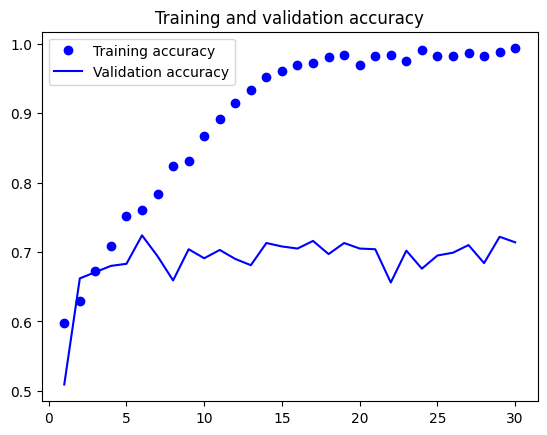

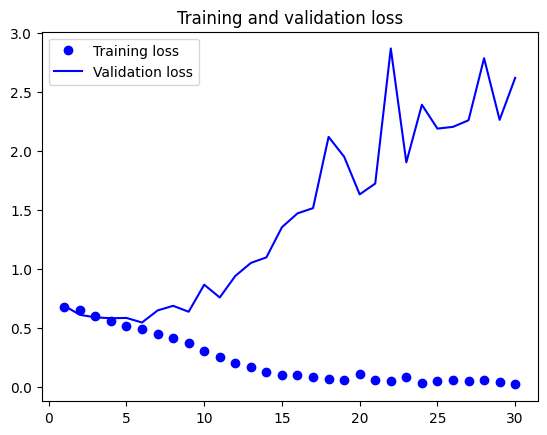

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()


In [ ]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

15/63 ━━━━━━━━━━━━━━━━━━━━ 43s 898ms/step - accuracy: 0.6986 - loss: 0.6005

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_16907]